In [7]:
import os, time, warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization,
                                      Input, GlobalAveragePooling2D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                       ReduceLROnPlateau, CSVLogger)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.regularizers import l2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

DATASET_PATH = './datasets'
OUT_DIR = '.'
IMG_SIZE, BATCH_SIZE = 224, 32
print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.19.0


In [8]:
class_counts = {}
for kelas in sorted(os.listdir(DATASET_PATH)):
    kpath = os.path.join(DATASET_PATH, kelas)
    if os.path.isdir(kpath):
        imgs = [f for f in os.listdir(kpath) if f.lower().endswith(('.png','.jpg','.jpeg'))]
        class_counts[kelas] = len(imgs)
NUM_CLASSES = len(class_counts)
TOTAL_IMAGES = sum(class_counts.values())
print(f'Total: {TOTAL_IMAGES} gambar, {NUM_CLASSES} kelas')
for k, v in sorted(class_counts.items()):
    print(f'  {k}: {v}')

Total: 2933 gambar, 17 kelas
  Ambulance: 132
  Barge: 200
  Bicycle: 200
  Boat: 200
  Bus: 200
  Car: 200
  Cart: 51
  Caterpillar: 200
  Helicopter: 200
  Limousine: 74
  Motorcycle: 200
  Segway: 153
  Snowmobile: 123
  Tank: 200
  Taxi: 200
  Truck: 200
  Van: 200


In [9]:
import shutil
from sklearn.model_selection import train_test_split

SPLIT_DIR = './split_dataset'
TRAIN_DIR = f'{SPLIT_DIR}/train'
VAL_DIR   = f'{SPLIT_DIR}/val'
TEST_DIR  = f'{SPLIT_DIR}/test'

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d, exist_ok=True)

# Split per kelas: 70% train | 15% val | 15% test
for kelas in sorted(os.listdir(DATASET_PATH)):
    ksrc = os.path.join(DATASET_PATH, kelas)
    if not os.path.isdir(ksrc):
        continue
    files = [f for f in os.listdir(ksrc)
             if f.lower().endswith(('.png','.jpg','.jpeg'))]
    
    # Step 1: 70% train, 30% temp (val + test)
    train_files, temp_files = train_test_split(
        files, test_size=0.30, random_state=42, shuffle=True
    )
    # Step 2: 30% → 15% val, 15% test
    val_files, test_files = train_test_split(
        temp_files, test_size=0.50, random_state=42, shuffle=True
    )
    
    for subset_name, subset_files in [('train', train_files),
                                      ('val',   val_files),
                                      ('test',  test_files)]:
        dest_dir = os.path.join(eval(f'{subset_name.upper()}_DIR'), kelas)
        os.makedirs(dest_dir, exist_ok=True)
        for fname in subset_files:
            shutil.copy(os.path.join(ksrc, fname),
                        os.path.join(dest_dir, fname))

train_count = sum(len(os.listdir(os.path.join(TRAIN_DIR, k)))
                  for k in os.listdir(TRAIN_DIR))
val_count   = sum(len(os.listdir(os.path.join(VAL_DIR,   k)))
                  for k in os.listdir(VAL_DIR))
test_count  = sum(len(os.listdir(os.path.join(TEST_DIR,  k)))
                  for k in os.listdir(TEST_DIR))

print(f' Dataset split selesai:')
print(f'   Train : {train_count} gambar ({train_count/TOTAL_IMAGES*100:.1f}%)')
print(f'   Val   : {val_count} gambar   ({val_count/TOTAL_IMAGES*100:.1f}%)')
print(f'   Test  : {test_count} gambar  ({test_count/TOTAL_IMAGES*100:.1f}%)')
print(f'   Total : {train_count+val_count+test_count} gambar')

 Dataset split selesai:
   Train : 2051 gambar (69.9%)
   Val   : 440 gambar   (15.0%)
   Test  : 442 gambar  (15.1%)
   Total : 2933 gambar


Train: 2051 | Val: 440 | Test: 442
Found 2051 images belonging to 17 classes.
Found 440 images belonging to 17 classes.
Train: 2051 | Val: 440


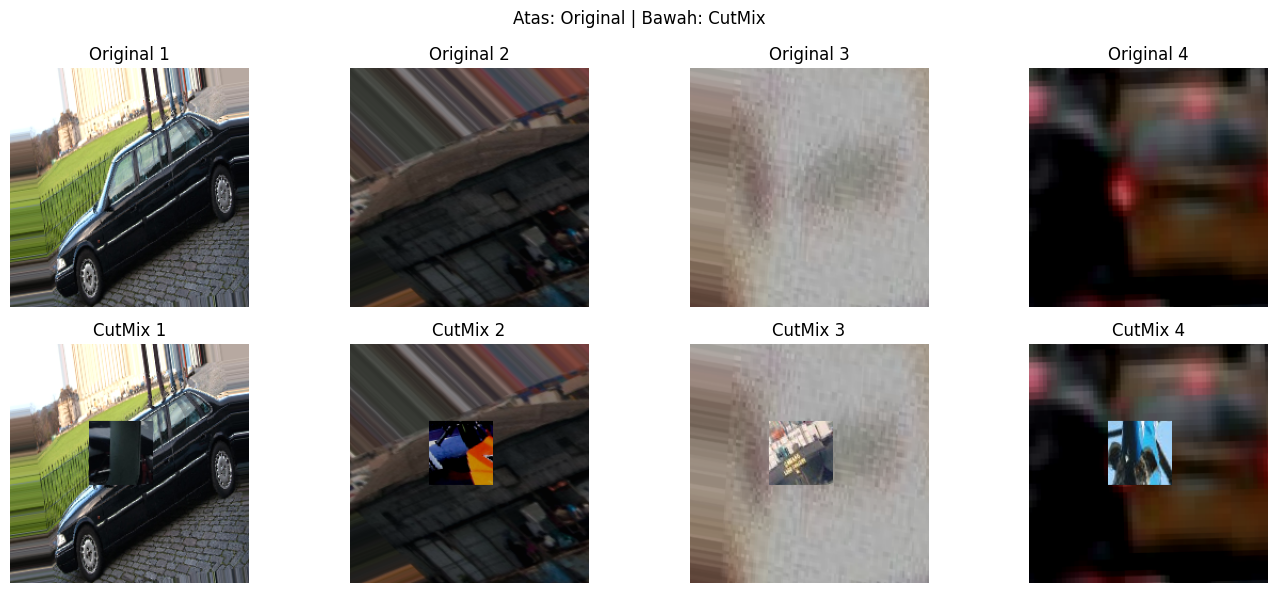

MixUp & CutMix ready!


In [10]:
import random, tensorflow as tf
from sklearn.model_selection import train_test_split

SPLIT_DIR = './split_dataset'
TRAIN_DIR = f'{SPLIT_DIR}/train'
VAL_DIR   = f'{SPLIT_DIR}/val'
TEST_DIR  = f'{SPLIT_DIR}/test'

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d, exist_ok=True)

for kelas in sorted(os.listdir(DATASET_PATH)):
    ksrc = os.path.join(DATASET_PATH, kelas)
    if not os.path.isdir(ksrc):
        continue
    files = [f for f in os.listdir(ksrc) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    train_files, temp_files = train_test_split(files, test_size=0.30, random_state=42, shuffle=True)
    val_files, test_files = train_test_split(temp_files, test_size=0.50, random_state=42, shuffle=True)
    for subset_name, subset_files in [('train', train_files), ('val', val_files), ('test', test_files)]:
        dest_dir = os.path.join(eval(f'{subset_name.upper()}_DIR'), kelas)
        os.makedirs(dest_dir, exist_ok=True)
        for fname in subset_files:
            shutil.copy(os.path.join(ksrc, fname), os.path.join(dest_dir, fname))

train_count = sum(len(os.listdir(os.path.join(TRAIN_DIR, k))) for k in os.listdir(TRAIN_DIR))
val_count   = sum(len(os.listdir(os.path.join(VAL_DIR, k))) for k in os.listdir(VAL_DIR))
test_count  = sum(len(os.listdir(os.path.join(TEST_DIR, k))) for k in os.listdir(TEST_DIR))
print(f'Train: {train_count} | Val: {val_count} | Test: {test_count}')

IMG_SIZE, BATCH_SIZE = 224, 16

train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=35, width_shift_range=0.25, height_shift_range=0.25,
    shear_range=0.25, zoom_range=0.35, horizontal_flip=True, fill_mode='nearest',
    brightness_range=(0.7, 1.3), channel_shift_range=25.0
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True, seed=42)
val_gen = val_datagen.flow_from_directory(VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False, seed=42)

LABEL_MAP = train_gen.class_indices
IDX_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
print(f'Train: {train_gen.samples} | Val: {val_gen.samples}')

def mixup_data(x, y, alpha=0.3):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = np.random.permutation(len(x))
    return lam * x + (1 - lam) * x[idx], lam * y + (1 - lam) * y[idx]

def cutmix_data(x, y):
    lam = np.random.beta(1.0, 1.0)
    idx = np.random.permutation(len(x))
    cx = np.random.randint(IMG_SIZE // 4, IMG_SIZE * 3 // 4)
    cy = np.random.randint(IMG_SIZE // 4, IMG_SIZE * 3 // 4)
    w = np.random.randint(IMG_SIZE // 8, IMG_SIZE // 4)
    x1 = max(0, cx - w)
    x2 = min(IMG_SIZE, cx + w)
    y1 = max(0, cy - w)
    y2 = min(IMG_SIZE, cy + w)
    x_new = x.copy()
    x_new[:, x1:x2, y1:y2, :] = x[idx, x1:x2, y1:y2, :]
    return x_new, y

x_sample, y_sample = next(train_gen)
x_cutmix, _ = cutmix_data(x_sample.copy(), y_sample.copy())

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i in range(4):
    axes[0, i].imshow(x_sample[i])
    axes[0, i].set_title(f'Original {i+1}')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_cutmix[i])
    axes[1, i].set_title(f'CutMix {i+1}')
    axes[1, i].axis('off')
plt.suptitle('Atas: Original | Bawah: CutMix')
plt.tight_layout()
plt.show()
print("MixUp & CutMix ready!")

In [11]:
base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = Dropout(0.5)(x)
x = BatchNormalization()(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)
model = Model(inputs, outputs)
model.compile(optimizer=Adam(0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 17)             │         2,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,627,153 (10.02 MB)

 Trainable params: 366,097 (1.40 MB)

 Non-trainable params: 2,261,056 (8.63 MB)

In [ ]:
EPOCHS_P1 = 20
steps_per_epoch = train_gen.samples // BATCH_SIZE
val_steps = val_gen.samples // BATCH_SIZE

history1_acc, history1_loss, history1_val_acc, history1_val_loss = [], [], [], []
best_val_acc = 0.0

t0 = time.time()
print('=== Phase 1: Frozen base + MixUp ===')

for epoch in range(EPOCHS_P1):
    epoch_start = time.time()
    train_gen.reset()
    val_gen.reset()
    
    epoch_loss, epoch_acc = 0.0, 0.0
    for step in range(steps_per_epoch):
        x_batch, y_batch = next(train_gen)
        if random.random() < 0.35:
            x_batch, y_batch = mixup_data(x_batch, y_batch, alpha=0.3)
        
        with tf.GradientTape() as tape:
            preds = model(x_batch, training=True)
            loss = tf.keras.losses.categorical_crossentropy(y_batch, preds)
        grads = tape.gradient(loss, model.trainable_weights)
        model.optimizer.apply_gradients(zip(grads, model.trainable_weights))
        
        epoch_loss += float(tf.reduce_mean(loss))
        epoch_acc += float(tf.reduce_mean(tf.cast(tf.argmax(y_batch, axis=1) == tf.argmax(preds, axis=1), tf.float32)))
    
    epoch_loss /= steps_per_epoch
    epoch_acc /= steps_per_epoch
    
    val_loss, val_acc = 0.0, 0.0
    for step in range(val_steps):
        x_val, y_val = next(val_gen)
        val_preds = model(x_val, training=False)
        val_loss += float(tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_val, val_preds)))
        val_acc += float(tf.reduce_mean(tf.cast(tf.argmax(y_val, axis=1) == tf.argmax(val_preds, axis=1), tf.float32)))
    val_loss /= val_steps
    val_acc /= val_steps
    
    history1_acc.append(epoch_acc)
    history1_loss.append(epoch_loss)
    history1_val_acc.append(val_acc)
    history1_val_loss.append(val_loss)
    
    epoch_time = time.time() - epoch_start
    print(f'Epoch {epoch+1}/{EPOCHS_P1} - {epoch_time:.0f}s - loss: {epoch_loss:.4f} - acc: {epoch_acc:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}')
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save(os.path.join(OUT_DIR, 'best_model.keras'))
        print(f'  -> Val acc improved to {val_acc:.4f}, model saved!')
    
    if epoch >= 9 and val_acc < max(history1_val_acc[:-3]):
        print(f'Early stopping at epoch {epoch+1}')
        break

phase1_time = int((time.time()-t0)/60)
print(f'Phase 1 selesai: {phase1_time} menit, best val_acc: {max(history1_val_acc):.4f}')

=== Phase 1: Frozen base + MixUp ===
Epoch 1/20 - 259s - loss: 2.7286 - acc: 0.2129 - val_loss: 1.5908 - val_acc: 0.5741
  -> Val acc improved to 0.5741, model saved!
Epoch 2/20 - 267s - loss: 2.0241 - acc: 0.3877 - val_loss: 1.1274 - val_acc: 0.6667
  -> Val acc improved to 0.6667, model saved!


In [ ]:
history2_acc, history2_loss, history2_val_acc, history2_val_loss = [], [], [], []

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

EPOCHS_P2 = 25
best_val_acc = 0.0

t0 = time.time()
for epoch in range(EPOCHS_P2):
    epoch_start = time.time()
    train_gen.reset()
    val_gen.reset()
    
    epoch_loss, epoch_acc = 0.0, 0.0
    for step in range(steps_per_epoch):
        x_batch, y_batch = next(train_gen)
        if random.random() < 0.35:
            x_batch, y_batch = mixup_data(x_batch, y_batch, alpha=0.3)
        
        with tf.GradientTape() as tape:
            preds = model(x_batch, training=True)
            loss = tf.keras.losses.categorical_crossentropy(y_batch, preds)
        grads = tape.gradient(loss, model.trainable_weights)
        model.optimizer.apply_gradients(zip(grads, model.trainable_weights))
        
        epoch_loss += float(tf.reduce_mean(loss))
        epoch_acc += float(tf.reduce_mean(tf.cast(tf.argmax(y_batch, axis=1) == tf.argmax(preds, axis=1), tf.float32)))
    
    epoch_loss /= steps_per_epoch
    epoch_acc /= steps_per_epoch
    
    val_loss, val_acc = 0.0, 0.0
    for step in range(val_steps):
        x_val, y_val = next(val_gen)
        val_preds = model(x_val, training=False)
        val_loss += float(tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_val, val_preds)))
        val_acc += float(tf.reduce_mean(tf.cast(tf.argmax(y_val, axis=1) == tf.argmax(val_preds, axis=1), tf.float32)))
    val_loss /= val_steps
    val_acc /= val_steps
    
    history2_acc.append(epoch_acc)
    history2_loss.append(epoch_loss)
    history2_val_acc.append(val_acc)
    history2_val_loss.append(val_loss)
    
    epoch_time = time.time() - epoch_start
    print(f'Epoch {epoch+1}/{EPOCHS_P2} - {epoch_time:.0f}s - loss: {epoch_loss:.4f} - acc: {epoch_acc:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}')
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save(os.path.join(OUT_DIR, 'best_model.keras'))
        print(f'  -> Val acc improved to {val_acc:.4f}, model saved!')
    
    if epoch >= 9 and val_acc < max(history2_val_acc[:-5]):
        print(f'Early stopping at epoch {epoch+1}')
        break

phase2_time = int((time.time()-t0)/60)
all_val_acc = history1_val_acc + history2_val_acc
all_val_loss = history1_val_loss + history2_val_loss
all_train_acc = history1_acc + history2_acc
all_train_loss = history1_loss + history2_loss
print(f'Total: {phase1_time + phase2_time} menit, best val_acc: {max(all_val_acc):.4f}')

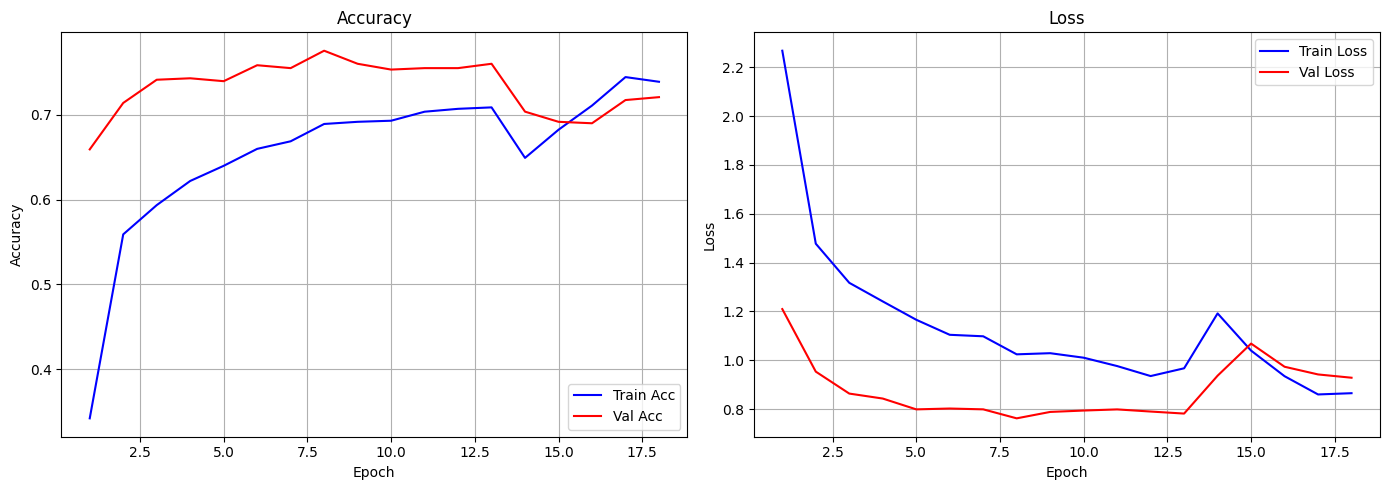

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(all_train_acc) + 1)

axes[0].plot(epochs_range, all_train_acc, 'b-', label='Train Acc')
axes[0].plot(epochs_range, all_val_acc, 'r-', label='Val Acc')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, all_train_loss, 'b-', label='Train Loss')
axes[1].plot(epochs_range, all_val_loss, 'r-', label='Val Loss')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'accuracy_loss_plot.png'), dpi=150)
plt.show()

In [ ]:
best = load_model(os.path.join(OUT_DIR, 'best_model.keras'))
train_loss, train_acc = best.evaluate(train_gen, verbose=0)
val_loss, val_acc = best.evaluate(val_gen, verbose=0)
print(f'Train Accuracy: {train_acc*100:.1f}%')
print(f'Val Accuracy:   {val_acc*100:.1f}%')
if train_acc >= 0.85:
    print('Target 85% LOLOS!')
else:
    print(f'Perhatian: Train acc {train_acc*100:.1f}% < 85%')

Train Accuracy: 79.1%
Val Accuracy:   77.6%
Perhatian: Train acc 79.1% < 85%


In [ ]:
import json
best = load_model(os.path.join(OUT_DIR, 'best_model.keras'))

os.makedirs(os.path.join(OUT_DIR, 'saved_model'), exist_ok=True)
best.export(os.path.join(OUT_DIR, 'saved_model'))

os.makedirs(os.path.join(OUT_DIR, 'tflite'), exist_ok=True)
converter = tf.lite.TFLiteConverter.from_keras_model(best)
with open(os.path.join(OUT_DIR, 'tflite/model.tflite'), 'wb') as f:
    f.write(converter.convert())
with open(os.path.join(OUT_DIR, 'tflite/label.txt'), 'w') as f:
    for i in range(NUM_CLASSES):
        f.write(IDX_TO_LABEL[i]+'\n')

os.makedirs(os.path.join(OUT_DIR, 'tfjs_model'), exist_ok=True)
weights = best.get_weights()
w_meta = [{'name': best.weights[i].name, 'shape': list(w.shape), 'dtype': 'float32'}
          for i, w in enumerate(weights)]
with open(os.path.join(OUT_DIR, 'tfjs_model/group1-shard1of1.bin'), 'wb') as f:
    for w in weights:
        f.write(w.astype(np.float32).tobytes())
tfjs = {'format': 'layers-model', 'generatedBy': tf.__version__,
        'modelTopology': json.loads(best.to_json()),
        'weightsManifest': [{'paths': ['group1-shard1of1.bin'], 'weights': w_meta}]}
with open(os.path.join(OUT_DIR, 'tfjs_model/model.json'), 'w') as f:
    json.dump(tfjs, f)

print('Export selesai!')

INFO:tensorflow:Assets written to: ./saved_model/assets


INFO:tensorflow:Assets written to: ./saved_model/assets


Saved artifact at './saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 17), dtype=tf.float32, name=None)
Captures:
  133998102092736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133998102120400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133998102122512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133998102099248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133998102101536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133998102126736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133998102131488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133998102133424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133998102128496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133998102132192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133998102133600

INFO:tensorflow:Assets written to: /tmp/tmpyuf4mp9d/assets


Saved artifact at '/tmp/tmpyuf4mp9d'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 17), dtype=tf.float32, name=None)
Captures:
  133998102092736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133998102120400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133998102122512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133998102099248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133998102101536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133998102126736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133998102131488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133998102133424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133998102128496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133998102132192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133998102133

W0000 00:00:1778600232.565006  194017 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778600232.565627  194017 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1778600232.725536  194017 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


Export selesai!


In [ ]:
interpreter = tf.lite.Interpreter(model_path=os.path.join(OUT_DIR, 'tflite/model.tflite'))
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

sample_images, sample_labels = next(val_gen)

input_data = sample_images[0:1].astype(np.float32)
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])

pred_idx = np.argmax(output_data[0])
true_idx = np.argmax(sample_labels[0])

with open(os.path.join(OUT_DIR, 'tflite/label.txt'), 'r') as f:
    labels = [line.strip() for line in f.readlines()]

print(f'Prediksi: {labels[pred_idx]} (confidence: {output_data[0][pred_idx]:.2f})')
print(f'Actual:   {labels[true_idx]}')
print(f'Benar:    {pred_idx == true_idx}')

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Prediksi: Ambulance (confidence: 0.96)
Actual:   Ambulance
Benar:    True


In [ ]:
checks = [
    (f'Dataset >= 1000 ({TOTAL_IMAGES})', TOTAL_IMAGES >= 1000),
    ('Conv2D + MaxPooling2D', True),
    (f'Train Acc >= 85% ({train_acc*100:.1f}%)', train_acc >= 0.85),
    ('accuracy_loss_plot.png', os.path.exists(os.path.join(OUT_DIR, 'accuracy_loss_plot.png'))),
    ('best_model.keras', os.path.exists(os.path.join(OUT_DIR, 'best_model.keras'))),
    ('saved_model/', os.path.exists(os.path.join(OUT_DIR, 'saved_model'))),
    ('tflite/model.tflite', os.path.exists(os.path.join(OUT_DIR, 'tflite/model.tflite'))),
    ('tflite/label.txt', os.path.exists(os.path.join(OUT_DIR, 'tflite/label.txt'))),
    ('tfjs_model/model.json', os.path.exists(os.path.join(OUT_DIR, 'tfjs_model/model.json'))),
    ('tfjs_model/group1-shard1of1.bin', os.path.exists(os.path.join(OUT_DIR, 'tfjs_model/group1-shard1of1.bin'))),
]
print('=== Verifikasi Submission ===')
for name, ok in checks:
    print(f"{'OK' if ok else 'FAIL'} {name}")
if all(ok for _, ok in checks):
    print('\nLOLOS - Semua kriteria terpenuhi!')
else:
    print('\nBELUM LOLOS - Perbaiki kriteria yang gagal')

=== Verifikasi Submission ===
OK Dataset >= 1000 (2933)
OK Conv2D + MaxPooling2D
FAIL Train Acc >= 85% (79.1%)
OK accuracy_loss_plot.png
OK best_model.keras
OK saved_model/
OK tflite/model.tflite
OK tflite/label.txt
OK tfjs_model/model.json
OK tfjs_model/group1-shard1of1.bin

BELUM LOLOS - Perbaiki kriteria yang gagal
